# Heart-disease risk from Apple Watch / HealthKit data

The Kaggle [heart-failure dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) ships 11 clinical features. Most cannot be obtained from a wrist wearable, so we train only on the subset an Apple Watch + HealthKit health profile can supply:

| Kaggle feature | Watch source | Kept |
| --- | --- | --- |
| `Age` | HealthKit characteristic (DOB) | yes |
| `Sex` | HealthKit characteristic | yes |
| `MaxHR` | derived from heart-rate sensor | yes |
| `RestingECG` | watch ECG uses a different taxonomy | no |
| `RestingBP`, `Cholesterol`, `FastingBS`, `ChestPainType`, `ExerciseAngina`, `Oldpeak`, `ST_Slope` | not available on a watch | no |
| `HeartDisease` | label | target |

**Caveat on `MaxHR`:** in this dataset it is the max heart rate during a *controlled exercise stress test*. An Apple Watch reports max HR from everyday/workout activity, which usually sits lower. Treat live watch values as an approximation of this feature.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# Resolve data path whether the notebook runs from notebooks/ or the project root.
DATA_PATH = next(p for p in [Path("../data/heart.csv"), Path("data/heart.csv")] if p.exists())
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Restrict to the watch-available features

In [2]:
NUMERIC_FEATURES = ["Age", "MaxHR"]
CATEGORICAL_FEATURES = ["Sex"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "HeartDisease"

data = df[FEATURES + [TARGET]].copy()
print("Missing values:\n", data.isna().sum(), sep="")
print(f"\nPositive (heart-disease) rate: {data[TARGET].mean():.3f}")
data.describe(include="all")

Missing values:
Age             0
MaxHR           0
Sex             0
HeartDisease    0
dtype: int64

Positive (heart-disease) rate: 0.553


,Age,MaxHR,Sex,HeartDisease
count,918.000000,918.000000,918,918.000000
unique,NaN,NaN,2,NaN
top,NaN,NaN,M,NaN
freq,NaN,NaN,725,NaN
mean,53.510893,136.809368,NaN,0.553377
std,9.432617,25.460334,NaN,0.497414
min,28.000000,60.000000,NaN,0.000000
25%,47.000000,120.000000,NaN,0.000000
50%,54.000000,138.000000,NaN,1.000000
75%,60.000000,156.000000,NaN,1.000000


## 2. Exploratory data analysis

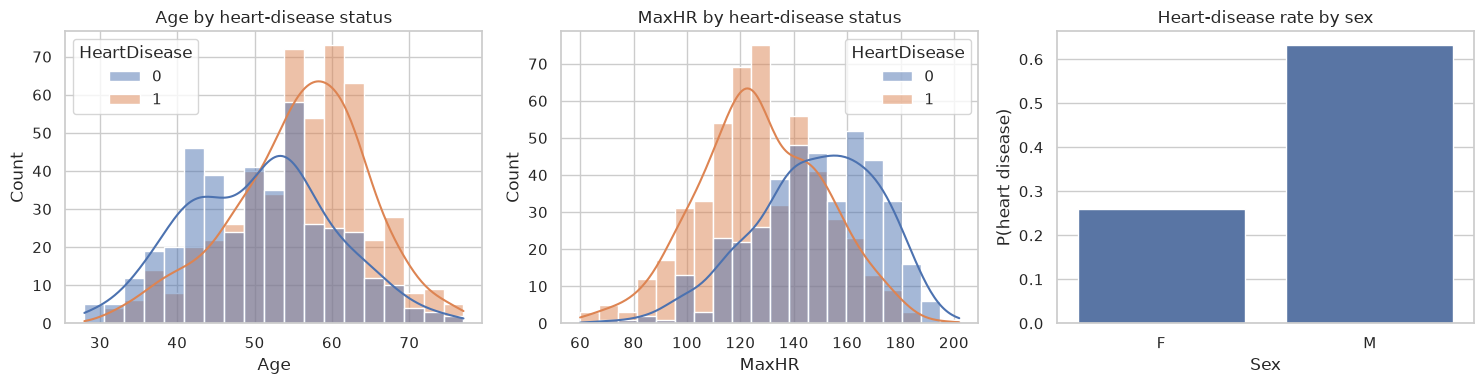

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=data, x="Age", hue=TARGET, kde=True, ax=axes[0])
axes[0].set_title("Age by heart-disease status")
sns.histplot(data=data, x="MaxHR", hue=TARGET, kde=True, ax=axes[1])
axes[1].set_title("MaxHR by heart-disease status")
sns.barplot(
    data=data.groupby("Sex")[TARGET].mean().reset_index(), x="Sex", y=TARGET, ax=axes[2]
)
axes[2].set_title("Heart-disease rate by sex")
axes[2].set_ylabel("P(heart disease)")
plt.tight_layout()
plt.show()

Higher age and **lower** MaxHR both track with heart disease, and the positive rate is markedly higher for male patients. These are exactly the three signals the model has to work with.

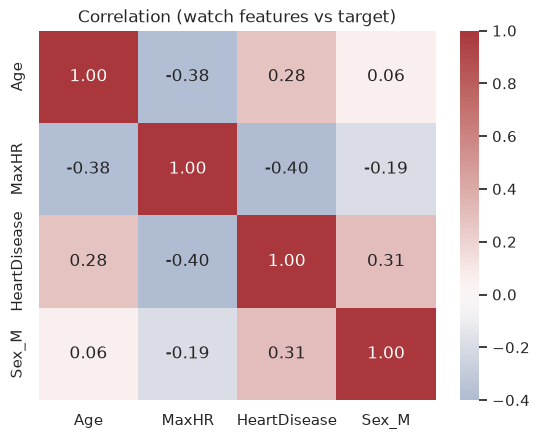

In [4]:
corr = data.assign(Sex_M=(data["Sex"] == "M").astype(int)).drop(columns=["Sex"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation (watch features vs target)")
plt.show()

## 3. Train / test split and preprocessing

In [5]:
X, y = data[FEATURES], data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(drop="if_binary"), CATEGORICAL_FEATURES),
    ]
)
print(f"train={len(X_train)}  test={len(X_test)}")

train=734  test=184


## 4. Model selection (5-fold CV ROC-AUC)

In [6]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for name, est in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name:<24} {scores.mean():.4f} +/- {scores.std():.4f}")

best_name = max(cv_scores, key=lambda k: cv_scores[k].mean())
print(f"\nBest: {best_name}")

logistic_regression      0.7686 +/- 0.0357


random_forest            0.7068 +/- 0.0324


hist_gradient_boosting   0.7341 +/- 0.0440

Best: logistic_regression


## 5. Fit the best model and evaluate on the held-out test set

Test ROC-AUC: 0.8085

              precision    recall  f1-score   support

           0      0.724     0.671     0.696        82
           1      0.750     0.794     0.771       102

    accuracy                          0.739       184
   macro avg      0.737     0.732     0.734       184
weighted avg      0.738     0.739     0.738       184



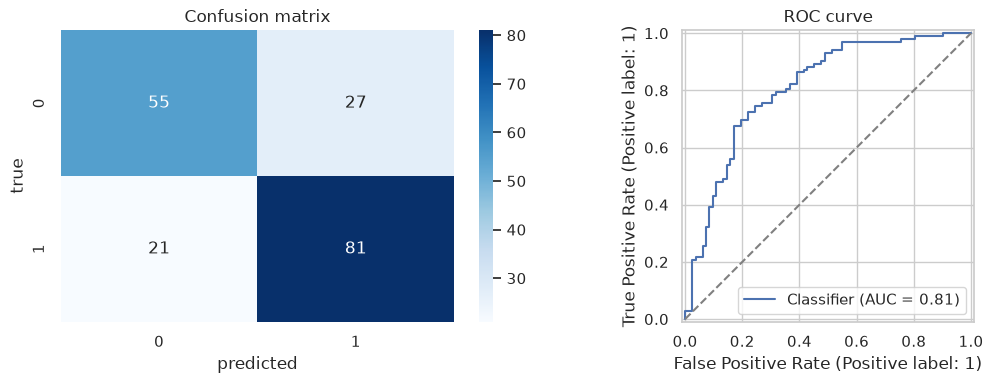

In [7]:
best = Pipeline([("prep", preprocessor), ("model", models[best_name])])
best.fit(X_train, y_train)

proba = best.predict_proba(X_test)[:, 1]
pred = best.predict(X_test)
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba):.4f}\n")
print(classification_report(y_test, pred, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_title("ROC curve")
plt.tight_layout()
plt.show()

## 6. What the model learned

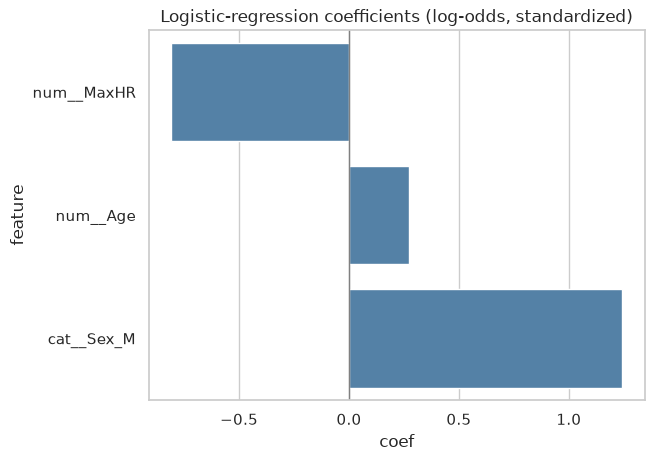

In [8]:
if best_name == "logistic_regression":
    feat_names = best.named_steps["prep"].get_feature_names_out()
    coefs = best.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs}).sort_values("coef")
    sns.barplot(data=coef_df, x="coef", y="feature", color="steelblue")
    plt.title("Logistic-regression coefficients (log-odds, standardized)")
    plt.axvline(0, color="grey", lw=1)
    plt.show()
    coef_df

## Conclusion

On just **Age, Sex, and MaxHR** the model reaches a held-out ROC-AUC around **0.81** — useful as a watch-driven *screening* signal, not a diagnosis. The dropped clinical features (`ST_Slope`, `ChestPainType`, `Oldpeak`) carry most of the dataset's predictive power, so this is the realistic ceiling for a wrist-only model. Use the predicted probability to triage who should get a proper clinical work-up.

`train.py` reproduces this end to end and saves the fitted pipeline to `models/heart_watch_model.joblib`.